In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
# from mount_drive import mount_s_drive

In [2]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from hyperion_utils import *

In [3]:
def getCovariatePreprocessor(aKeepColumns):
    return ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

In [4]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=10)
    myImputer.set_output(transform="pandas")
    # myCovariates = getCovariatePreprocessor(['bin__' + 'treatment_hypothermia'])
    # myImputer.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer)]

In [5]:
myPredictorsDf, X_train, X_test, y_train, y_test = \
            getTrainTestFunctions(aPredictedColumn = 'hospital_mortality', 
                                     aTreatmentColumn = 'groupe', 
                                     aSkipTemp = False) 

In [6]:
Pipeline(getDefaultPipelineSteps(X_train))

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=OneHotEncoder(handle_unknown='ignore',
                                                           sparse_output=False),
                                   transformers=[('num', StandardScaler(),
                                                  Index(['J0_TAILLE', 'J0_POIDS', 'J0_BMI', 'J0_AGE', 'J0_PAS', 'J0_PAD',
       'J0_PAM', 'J0_FC', 'J0_SPO2', 'J0_GLASGOW', 'J0_TEMP', 'J0_IGSII',
       'J0_CHARLSON', 'J0_CAUSE2_ACR', 'J0_NOFLOW', 'J0_LOWFLOW',
       'J0_ADRE_DO...
       'J0_AMINE', 'J0_NORA', 'J0_ADRE2', 'J0_DOBU', 'J0_DOPA', 'ECG',
       'ECG_ANOMALI', 'ECG_SUS_ST', 'ECG_SOUS_ST', 'ECG_BAVI', 'ECG_BAVII',
       'ECG_BAVIII', 'ECG_BBG', 'ECG_BBD', 'ECG_TACHICARD', 'ECG_FIBRIL',
       'ECG_SALV_VENT', 'ECG_FLUTER', 'ECG_SALV_SUPRA', 'EI_EI',
       'EI_HEMOSEVER', 'EI_TRANSFUS', 'EI_INTRACER', 'EI_CHIR', 'EI_ECHO',
       'EI_DIURETIQ', 'EI_ANTIEPILEPTIQ', 'SEX'],
      dtype='object'))])),
                ('imputer', KNNImputer(n_neighbors=10))])

In [7]:
# def getDefaultPipelineSteps(X_train):
#     myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
#     myBinaryColumns = X_train.columns[X_train.nunique() == 2]
#     myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
#     return [('preprocessor', myPreprocessor), ('imputer', KNNImputer(n_neighbors=10)), \
#             ('sfs', SFS(estimator = XGBClassifier(max_depth = 10, n_estimators = 100, n_jobs=-1), 
#                         verbose =2, n_jobs=-1, k_features=50, forward=True, floating=True, cv=5))]

In [8]:
y_test.sum()

np.int64(143)

In [9]:
DefaultGrid = [
    {
        'clf': [XGBClassifier(eval_metric='logloss')],
        'clf__n_estimators': [25, ], 
        'clf__max_depth': [2,]
    },
    # {
    #     'clf': [XGBClassifier(eval_metric='logloss')],
    #     'clf__n_estimators': [50], 
    #     'clf__max_depth': [10]
    # }
    # {
    #     'clf': [DecisionTreeClassifier()],
    #     'clf__max_depth': [2, 5, 20, 50, None],
    #     'clf__class_weight': [None, 'balanced']
    # },
    # {
    #     'clf': [LogisticRegression(), SVC(probability=True)],
    #     'clf__C': [0.01, 0.1, 1, 10, 100]
    # }
    # {
    #     'clf': [KerasClassifier(model=build_model, epochs=30, batch_size=32, verbose=1)]
    # }
]
def gridSearchKFoldClassification(X_train, X_test, y_train, y_test, aScore = 'roc_auc', aGrid = DefaultGrid):
    kf = StratifiedKFold(n_splits=5, shuffle=True)
    myPipelineSteps = getDefaultPipelineSteps(X_train = X_train)
    myPipelineSteps.append(('clf', XGBClassifier()))
    myPipeline = Pipeline(myPipelineSteps)
    myGridSearchCv = GridSearchCV(myPipeline, aGrid, cv=kf, scoring=aScore, n_jobs=-1, verbose=3)
    myGridSearchCv.fit(X_train, y_train)
    myBestModel = myGridSearchCv.best_estimator_
    y_pred_proba = myBestModel.predict_proba(X_test)[:, 1]
    y_pred = myBestModel.predict(X_test)
    print(f'Best parameters: {myGridSearchCv.best_params_}')
    print(f'Best cross val {aScore} score: {myGridSearchCv.best_score_:.4f}')
    print(f'Area under the receiver operating curve on test set is {roc_auc_score(y_test, y_pred_proba):.4f}')
    print(f'Accuracy score on test set is {accuracy_score(y_test, y_pred):.4f}')
    return myGridSearchCv
myGridSearchCv = gridSearchKFoldClassification(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='roc_auc', aGrid = DefaultGrid)
myBestModel = myGridSearchCv.best_estimator_

Fitting 5 folds for each of 1 candidates, totalling 5 fits


[CV 4/5] END clf=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...), clf__max_depth=2, clf__n_estimators=25;, score=0.805 total time=   2.3s
[CV 3/5] END clf=XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_byno

In [10]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
y_pred_prob = myBestModel.predict_proba(X_test)[:, 1]
def bootstrap_auc_ci(y_true, y_score, n_bootstraps=2000, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []

    for _ in range(n_bootstraps):
        idx = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue  # skip invalid bootstrap
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))

    aucs = np.array(aucs)
    return (
        np.mean(aucs),
        np.percentile(aucs, 2.5),
        np.percentile(aucs, 97.5),
    )

auc, ci_low, ci_high = bootstrap_auc_ci(np.array(y_test), y_pred_prob)
print(f"AUC = {auc:.3f} (95% CI {ci_low:.3f}–{ci_high:.3f})")


AUC = 0.820 (95% CI 0.733–0.898)


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'HYPERION XGBoost Calibration Plot'}, xlabel='Mean predicted probability', ylabel='Observed event rate'>)

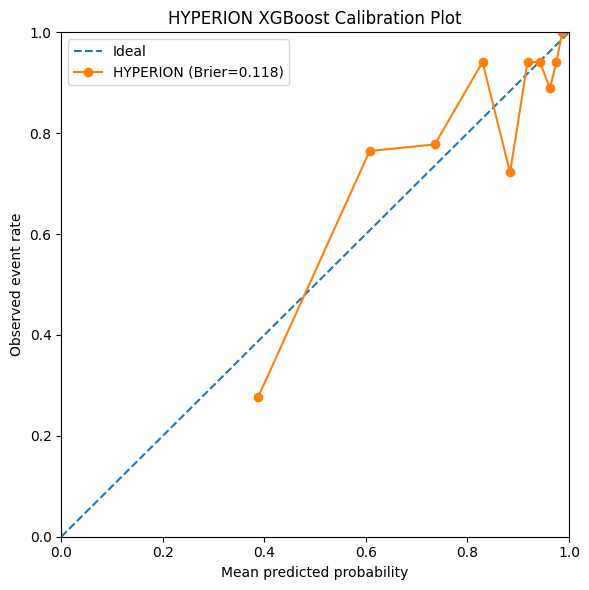

In [16]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def calibration_intercept_slope(y_true, y_prob, eps=1e-6):
    """
    Compute calibration intercept and slope by regressing outcome on logit(predicted probability).
    Ideal intercept = 0, slope = 1.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_prob = np.clip(y_prob, eps, 1 - eps)

    logit_p = np.log(y_prob / (1 - y_prob))
    X = sm.add_constant(logit_p)

    fit = sm.Logit(y_true, X).fit(disp=False)

    intercept = fit.params[0]
    slope = fit.params[1]

    return intercept, slope

def calibration_metrics(y_true, y_prob):
    """
    Return a small dict of discrimination + calibration metrics.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    intercept, slope = calibration_intercept_slope(y_true, y_prob)

    return {
        "n": len(y_true),
        "event_rate": float(np.mean(y_true)),
        "auc": float(roc_auc_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "calibration_intercept": float(intercept),
        "calibration_slope": float(slope),
    }

def plot_calibration_curve_one(y_true, y_prob, title="", n_bins=10, ax=None):
    """
    Reliability diagram / calibration curve.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    frac_pos, mean_pred = calibration_curve(
        y_true,
        y_prob,
        n_bins=n_bins,
        strategy="quantile"
    )

    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.plot(mean_pred, frac_pos, marker="o")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    return ax
def plot_calibration_curve_multi(model_preds, y_true, title="", n_bins=10):
    """
    model_preds: dict like {"XGBoost": probs1, "NN": probs2, "BART": probs3}
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle="--", label="Ideal")

    for model_name, y_prob in model_preds.items():
        frac_pos, mean_pred = calibration_curve(
            y_true,
            y_prob,
            n_bins=n_bins,
            strategy="quantile"
        )
        brier = brier_score_loss(y_true, y_prob)
        ax.plot(mean_pred, frac_pos, marker="o", label=f"{model_name} (Brier={brier:.3f})")

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed event rate")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    return fig, ax

def build_calibration_table(results_dict):
    """
    results_dict structure:
    {
        ("eICU", "Neuro", "XGBoost"): (y_true, y_prob),
        ("eICU", "Neuro", "NN"): (y_true, y_prob),
        ...
    }
    """
    rows = []

    for (dataset, outcome, model), (y_true, y_prob) in results_dict.items():
        m = calibration_metrics(y_true, y_prob)
        m.update({
            "dataset": dataset,
            "outcome": outcome,
            "model": model
        })
        rows.append(m)

    df = pd.DataFrame(rows)
    df = df[
        [
            "dataset", "outcome", "model", "n", "event_rate",
            "auc", "brier", "calibration_intercept", "calibration_slope"
        ]
    ].sort_values(["dataset", "outcome", "model"]).reset_index(drop=True)

    return df
results_dict = {
    ("eICU", "Mortality", "NN"): (y_test, y_pred_prob),
    # ...
}

calib_table = build_calibration_table(results_dict)
calib_table.round(3)
plot_calibration_curve_multi({"HYPERION":y_pred_prob}, y_test, "HYPERION XGBoost Calibration Plot")

In [17]:
calib_table

,dataset,outcome,model,n,event_rate,auc,brier,calibration_intercept,calibration_slope
0,eICU,Mortality,NN,175,0.817143,0.784309,0.117571,0.14825,0.836016


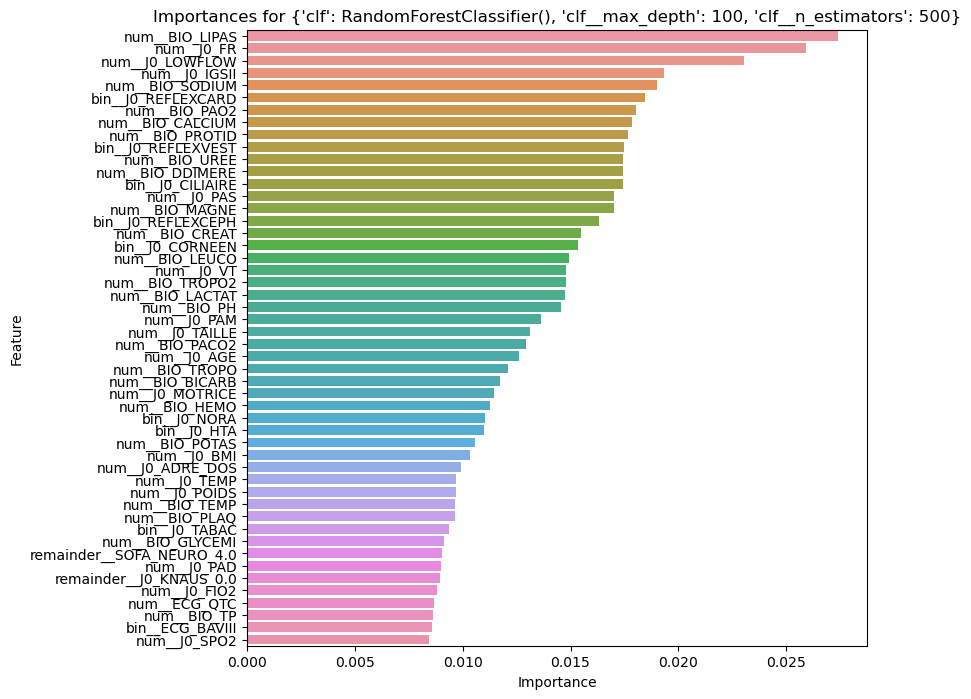

In [75]:
myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps.preprocessor.get_feature_names_out()), X_train, y_train)

In [76]:
myFeatureImportancesDf[myFeatureImportancesDf.Feature == 'bin__groupe']

,Feature,Importance
51,bin__groupe,0.001469


In [11]:
getTreatmentEffectDiff(aX = X_train, aY = y_train.reset_index().drop(columns='index'), aModel = myBestModel, \
                       aCategory = 'hospital_mortality', aGroup = 'groupe', aUseNeuralNetwork = False, aByGroup =False)

No effect difference


TypeError: object of type 'int' has no len()

In [57]:
getTreatmentEffectDiff(aX = X_test, aY = y_test.reset_index().drop(columns='index'), aModel = myBestModel, \
                       aCategory = 'CPC12', aGroup = 'groupe', aUseNeuralNetwork = False, aByGroup =False)

No effect difference


TypeError: object of type 'int' has no len()